In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation



In [2]:
df = pd.read_parquet('/content/ALL_2024_ENRICHED.parquet')
display(df.head())
df.info()

,PULocationID,request_hour,trip_cnt,lag_1h,lag_24h,holiday_ind,precipitation_ind,precipitation_mm
0,1,2024-01-25 06:00:00,1,NaN,NaN,0,1,6.1
1,1,2024-02-16 04:00:00,1,1.0,NaN,0,0,0.0
2,1,2024-04-15 04:00:00,1,1.0,NaN,0,0,0.0
3,1,2024-05-05 05:00:00,1,1.0,NaN,0,1,9.9
4,1,2024-07-14 15:00:00,1,1.0,NaN,0,0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2218006 entries, 0 to 2218005
Data columns (total 8 columns):
 #   Column             Dtype         
---  ------             -----         
 0   PULocationID       int32         
 1   request_hour       datetime64[us]
 2   trip_cnt           int64         
 3   lag_1h             float64       
 4   lag_24h            float64       
 5   holiday_ind        int64         
 6   precipitation_ind  int64         
 7   precipitation_mm   float64       
dtypes: datetime64[us](1), float64(3), int32(1), int64(3)
memory usage: 126.9 MB


**EDA**

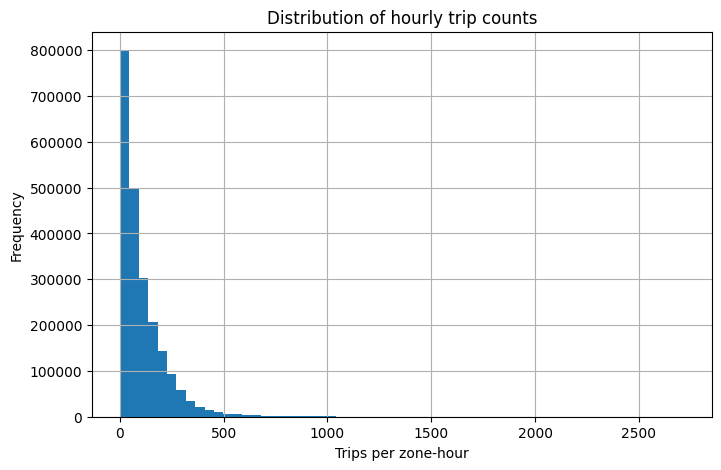

In [3]:


plt.figure(figsize=(8,5))
df["trip_cnt"].hist(bins=60)
plt.title("Distribution of hourly trip counts")
plt.xlabel("Trips per zone-hour")
plt.ylabel("Frequency")
plt.show()


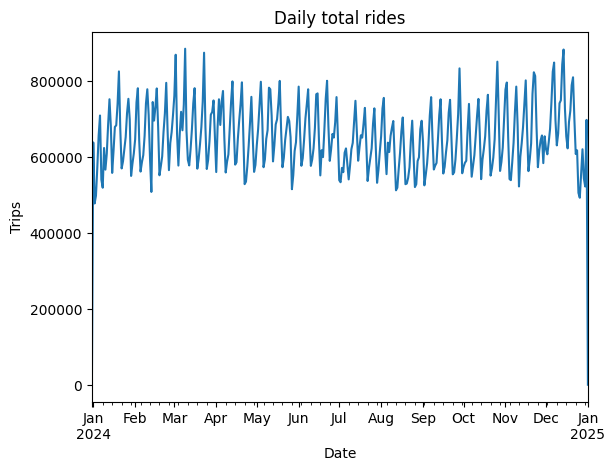

In [5]:
df.set_index("request_hour").resample("D")["trip_cnt"].sum().plot(title="Daily total rides")
plt.xlabel("Date")
plt.ylabel("Trips")
plt.show()


In [6]:
top_zones = df.groupby("PULocationID")["trip_cnt"].sum().sort_values(ascending=False).head(10)
top_zones


,trip_cnt
PULocationID,
138,4738335
132,4331163
79,3172444
61,3136821
230,2940406
161,2805144
231,2713823
68,2688563
37,2587645


In [7]:
rain_mean = df.groupby("precipitation_ind")["trip_cnt"].mean()
holiday_mean = df.groupby("holiday_ind")["trip_cnt"].mean()

print("Average trips per hour (rain=1):", rain_mean[1])
print("Average trips per hour (no rain=0):", rain_mean[0])
print("Average trips per hour (holiday=1):", holiday_mean[1])
print("Average trips per hour (non-holiday=0):", holiday_mean[0])


Average trips per hour (rain=1): 110.21109171681256
Average trips per hour (no rain=0): 106.3549762827603
Average trips per hour (holiday=1): 92.91780430598989
Average trips per hour (non-holiday=0): 108.43176834330005


In [8]:
corr = df[["trip_cnt","lag_1h","lag_24h","holiday_ind","precipitation_ind","precipitation_mm"]].corr()
corr["trip_cnt"].sort_values(ascending=False)


,trip_cnt
trip_cnt,1.000000
lag_1h,0.945838
lag_24h,0.882987
precipitation_mm,0.023887
precipitation_ind,0.016099
holiday_ind,-0.022397


In [9]:
df.isna().sum()

,0
PULocationID,0
request_hour,0
trip_cnt,0
lag_1h,262
lag_24h,6281
holiday_ind,0
precipitation_ind,0
precipitation_mm,217


In [10]:
# Fill weather gaps with 0 (no rain)
df["precipitation_mm"] = df["precipitation_mm"].fillna(0)

# Drop rows missing lag features (occur at beginning of each zones time series)
df = df.dropna(subset=["lag_1h", "lag_24h"])

# Add time features
df["hour"] = df["request_hour"].dt.hour
df["weekday"] = df["request_hour"].dt.dayofweek


**Modeling**

In [11]:
X = df[["PULocationID","lag_1h","lag_24h","holiday_ind","precipitation_ind","precipitation_mm","hour","weekday"]]
y = df["trip_cnt"]

#Jan-Oct train, Nov-Dec test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

#Choosing poisson because count data follows more simlarily to a Poisson process
# number of rides per time frame

#default params, need to hyperparameter tune
params = {
    "objective": "poisson",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "verbose": -1
}

model = lgb.train(
    params=params,
    train_set=train_data,
    valid_sets=[test_data],
    num_boost_round=500,
    callbacks=[
        early_stopping(stopping_rounds=30),
        log_evaluation(50)
    ]
)


Training until validation scores don't improve for 30 rounds
[50]	valid_0's rmse: 45.6191
[100]	valid_0's rmse: 31.1409
[150]	valid_0's rmse: 28.8781
[200]	valid_0's rmse: 28.1402
[250]	valid_0's rmse: 27.784
[300]	valid_0's rmse: 27.5451
[350]	valid_0's rmse: 27.3765
[400]	valid_0's rmse: 27.2411
[450]	valid_0's rmse: 27.1775
[500]	valid_0's rmse: 27.1483
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 27.1483


In [12]:
y_pred = model.predict(X_test)
print("R-squared:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))


R-squared: 0.949
RMSE: 27.15


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

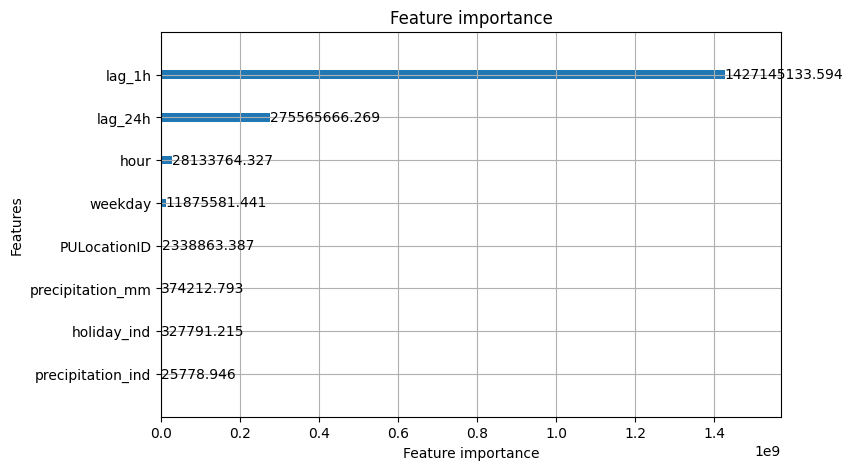

In [13]:
lgb.plot_importance(model, importance_type='gain', figsize=(8,5))


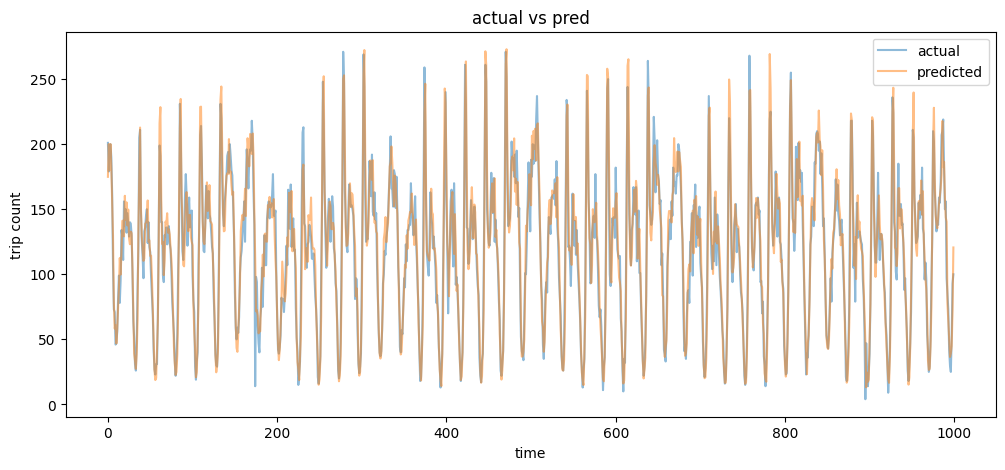

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:1000], label="actual", alpha=0.5)
plt.plot(y_pred[:1000], label="predicted", alpha=0.5)
plt.legend()
plt.title("actual vs pred")
plt.xlabel("time")
plt.ylabel("trip count")
plt.show()
